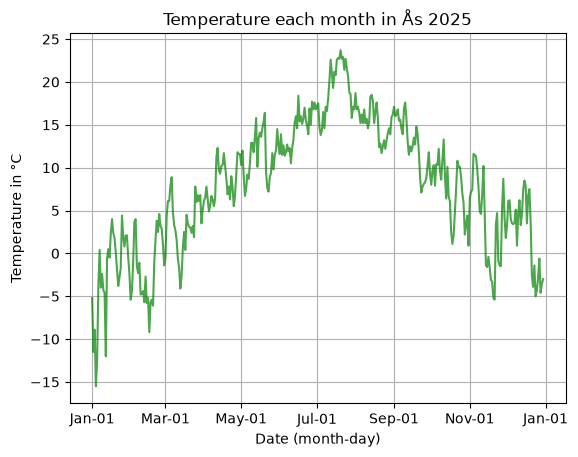

------SUMMARY TABLE 2025------
Mean temperature:      7.90 °C
Median temperature:    8.40 °C
Minimum temperature: -15.50 °C
Maximum temperature:  23.70 °C
------------------------------


In [76]:
#Main working folder

#Client id, getting started
import pandas as pd 
import requests
import matplotlib.pyplot as plt

client_id = open("../frost_client_id.txt").read().strip()

#Task 1: Temperature: 
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
'sources': 'SN17850',
'elements': 'mean(air_temperature P1D)',
'referencetime': '2025-01-01/2025-12-31',
}

# Get data from frost.met.no
response = requests.get(endpoint, parameters, auth=(client_id, ''))
assert response.status_code == 200

# convert response to JSON-format
data = response.json()

temperature_data = []
for day in data['data']:
    date = pd.Timestamp(day['referenceTime'])
    temp = None
    for observation in day['observations']:
        if observation['elementId'] == 'mean(air_temperature P1D)' and temp is None: 
            temp = observation['value']
    temperature_data.append((date, temp))

dataframe = pd.DataFrame(temperature_data, columns=['Date', 'Temperature'])
dataframe.set_index('Date', inplace=True)

# show month and day on x-axis, date is given as the first of each month.
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%d'))

# plotting data.
plt.plot(dataframe.index, dataframe['Temperature'], color='green', alpha=0.7)
plt.title('Temperature each month in Ås 2025')
plt.xlabel('Date (month-day)')
plt.ylabel('Temperature in °C')
plt.grid(True)
plt.show()

# Summary table containing mean, median, min and max temperatures. 
mean = dataframe['Temperature'].mean()
median = dataframe['Temperature'].median()
minimum_temp = dataframe['Temperature'].min()
maximum_temp = dataframe['Temperature'].max()

print("------SUMMARY TABLE 2025------")
print(f"Mean temperature: {mean:9.2f} °C")
print(f"Median temperature: {median:7.2f} °C")
print(f"Minimum temperature: {minimum_temp:.2f} °C")
print(f"Maximum temperature: {maximum_temp:6.2f} °C")
print("------------------------------")




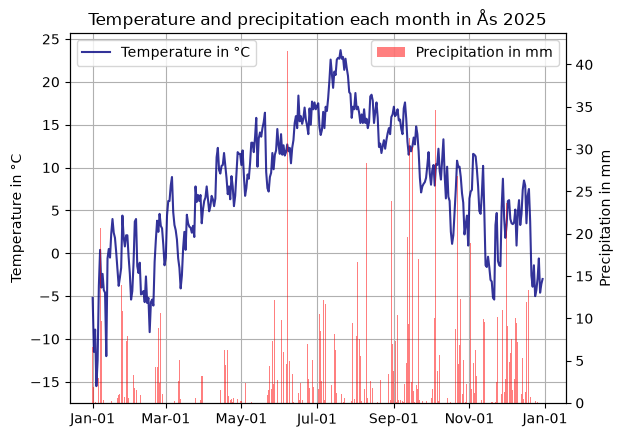

In [72]:
#Task 02: precipitation: 

# Get data, both temperature and precipitation, from frost.met.no

from matplotlib.pyplot import bar


parameters = {
'sources': 'SN17850',
'elements': 'mean(air_temperature P1D),sum(precipitation_amount P1D)',
'referencetime': '2025-01-01/2025-12-31',
}

response_02 = requests.get(endpoint, parameters, auth=(client_id, ''))
assert response_02.status_code == 200
data = response_02.json()


metrics = []
for day in data['data']:
    date = pd.Timestamp(day['referenceTime'])
    temp = None
    precip = 0.0
    for observation in day['observations']:
        if observation['elementId'] == 'mean(air_temperature P1D)' and temp is None:
            temp = observation['value']
        elif observation['elementId'] == 'sum(precipitation_amount P1D)':
            precip = observation['value']
    metrics.append((date, temp, precip))


dataframe_02 = pd.DataFrame(metrics, columns=['Date', 'Temperature', 'Precipitation'])
dataframe_02.set_index('Date', inplace=True)


# make a plot that shows both temperature and precipitation for 2025.
# we decided to use a bar chart for percipitation and a line chart for temperature.

plt.title('Temperature and precipitation each month in Ås 2025')

ax1 = plt.gca()
ax1.plot(dataframe_02.index, dataframe_02['Temperature'], color='navy', alpha = 0.8, label ='Temperature in °C')
ax1.set_ylabel('Temperature in °C')

ax2 = ax1.twinx()
ax2.bar(dataframe_02.index, dataframe_02['Precipitation'], color='red', alpha=0.5, label='Precipitation in mm')

ax2.set_ylabel('Precipitation in mm')



plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%d'))
plt.xlabel('Date (month-day)')

ax1.legend(loc='upper left'), ax2.legend(loc='upper right')
ax1.grid(True)
plt.show()

